# 고객 군집 분석 실습
- 실습 순서
1. 거래 데이터 확인
2. 결측치, 취소 거래, 비정상 거래 정리
3. 고객별 RFM 지표 생성
4. 데이터 스케일링 및 군집 수 선택
5. K-Means 군집화
6. 군집별 고객 특성 해석
7. 마케팅 관점에서 고객군 이름, 혜택 등 추가

## 1. 라이브러리 불러오기

In [113]:
# 운영체제 관련
import os
import warnings

# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt       # 날짜 처리

# scikit-learn 관련
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')  # 경고 메시지 무시

SEED = 42
sns.set_theme(style = 'whitegrid')

# 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 2. 데이터 불러오기

In [114]:
retail_df = pd.read_excel('data/Online Retail.xlsx')

retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. 데이터 기본 정보 확인

In [115]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [116]:
retail_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [117]:
retail_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Quantity,UnitPrice 에 있는 음수는 처리가 필요하다.  
CustomerID 가 없는 데이터는 삭제처리

In [118]:
cancel_count = retail_df['InvoiceNo'].astype(str).str.startswith('C').sum()

negative_quantity_count = (retail_df['Quantity'] <= 0).sum()
non_positive_price_count = (retail_df['UnitPrice'] <= 0).sum()

print(f"취소 거래 수 : {cancel_count}")
print(f"수량이 0 이하인 거래 수 : {negative_quantity_count}")
print(f"단가가 0 이하인 거래 수 : {non_positive_price_count}")

취소 거래 수 : 9288
수량이 0 이하인 거래 수 : 10624
단가가 0 이하인 거래 수 : 2517


## 4. 데이터 전처리
- CustomerID가 없는 거래 제거
- 최소된 거래 제거
- Quantity가 0 이하인 거래 제거
- UnitPrice가 0 이하인 거래 제거
- CustomerID가는 정수형으로 변환
- 거래금액 파생변수 sale_amount = Quantity * UnitPrice

In [119]:
df_clean = retail_df.copy()

# CustomerID가 없는 거래 제거
df_clean = df_clean.dropna(subset = ['CustomerID'])

# 최소된 거래 제거
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Quantity와 UnitPrice가 0 이하인 거래 제거
df_clean = df_clean[(df_clean['Quantity']>0) & (df_clean['UnitPrice']>0)]

# CustomerID가는 정수형으로 변환
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 거래금액 파생변수 sale_amount = Quantity * UnitPrice
df_clean['sale_amount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,sale_amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [120]:
print(f"전처리 전 : {retail_df.shape} ")
print(f"전처리 후 : {df_clean.shape} ")

전처리 전 : (541909, 8) 
전처리 후 : (397884, 9) 


## 5. 주요 변수 이상치 확인

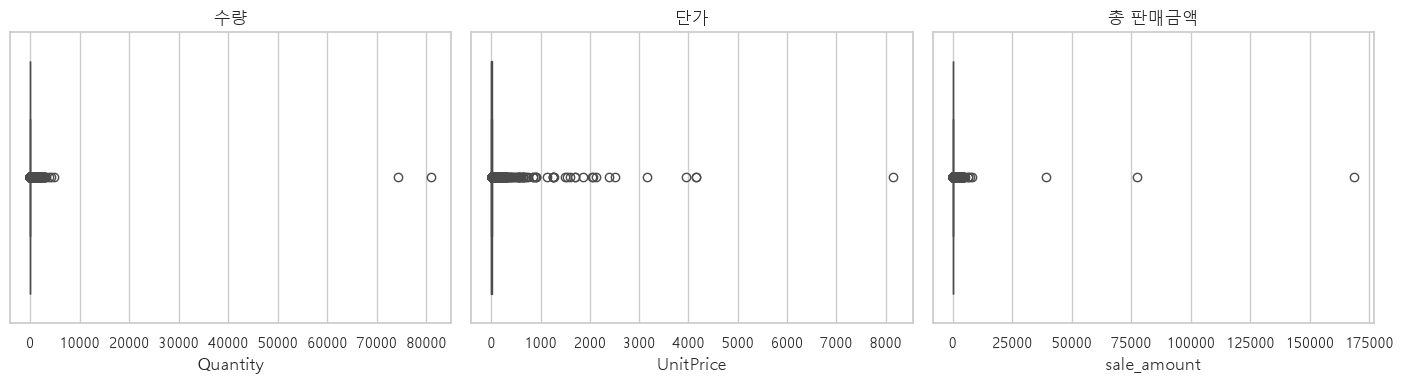

In [121]:
plt.figure(figsize= (14,4))
plt.subplot(1,3,1)
sns.boxplot(x=df_clean['Quantity'])
plt.title("수량")

plt.subplot(1,3,2)
sns.boxplot(x=df_clean['UnitPrice'])
plt.title("단가")

plt.subplot(1,3,3)
sns.boxplot(x=df_clean['sale_amount'])
plt.title("총 판매금액")

plt.tight_layout()
plt.show()

소수 고객의 구매 금액이 매우 큰 경우가 많다.  
실제 데이터이기 때문에 IQR 이상치 제거보다는 로그 변환정도 하면 약간 분포를 눌러줄 수 있다.

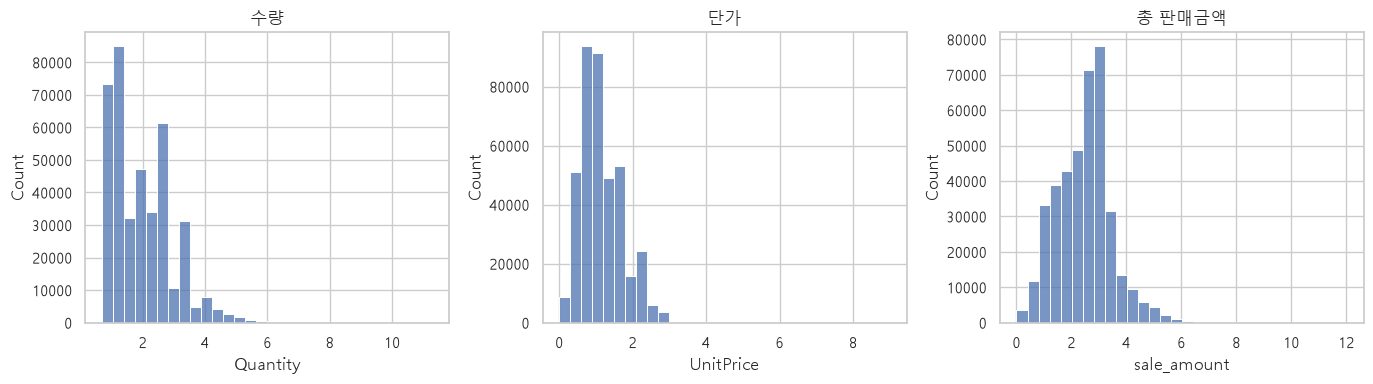

In [122]:
plt.figure(figsize= (14,4))

plt.subplot(1,3,1)
sns.histplot(np.log1p(df_clean['Quantity']),bins = 30)
plt.title("수량")

plt.subplot(1,3,2)
sns.histplot(np.log1p(df_clean['UnitPrice']),bins = 30)
plt.title("단가")

plt.subplot(1,3,3)
sns.histplot(np.log1p(df_clean['sale_amount']),bins = 30)
plt.title("총 판매금액")

plt.tight_layout()
plt.show()

## 6. 국가별 거래 현황 확인

In [123]:
country_counts = df_clean['Country'].sort_values

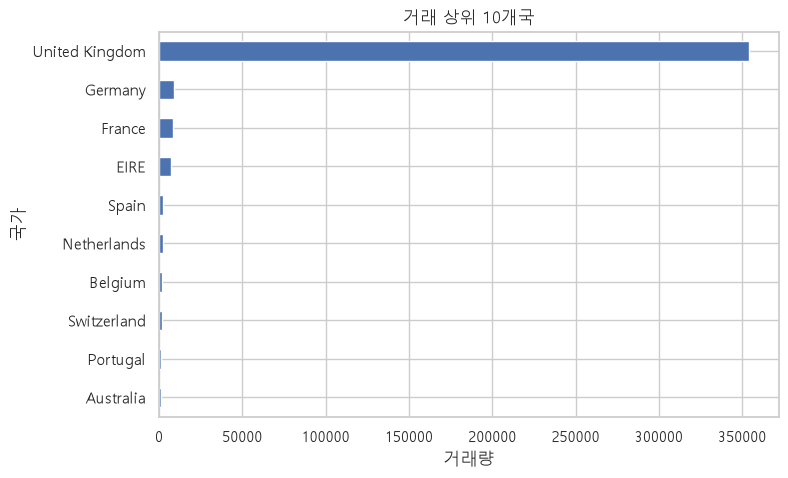

In [124]:
country_counts = df_clean['Country'].value_counts().head(10)
plt.figure(figsize=(8,5))
country_counts.sort_values().plot(kind='barh')
plt.title('거래 상위 10개국')
plt.xlabel('거래량')
plt.ylabel('국가')
plt.show()

In [125]:
customer_sales = (
    df_clean.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)
)
customer_sales.head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: sale_amount, dtype: float64

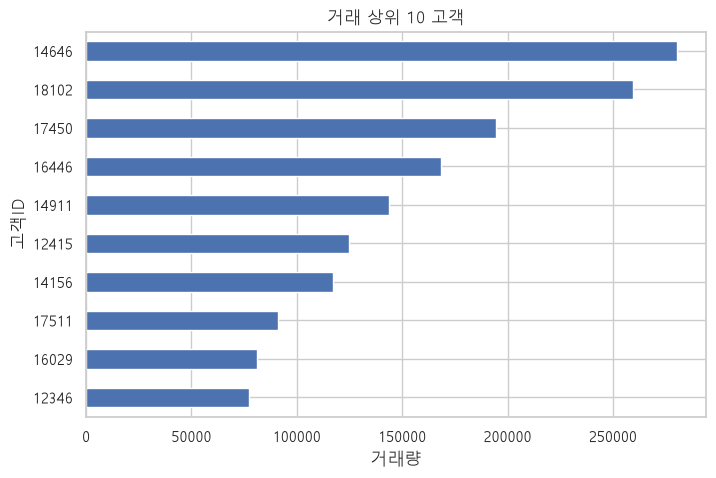

In [126]:
top10 = customer_sales.head(10).sort_values()

plt.figure(figsize=(8,5))
top10.plot(kind='barh')
plt.title('거래 상위 10 고객')
plt.xlabel('거래량')
plt.ylabel('고객ID')
plt.show()

In [127]:
# 상위 10% 고객이 차지하는 매출 비중 계산

total_customers = customer_sales.shape[0] # 전체 고객 수
top_10_percent_cnt = max(1,int(total_customers * 0.1))  # 상위 10% 고객 수

# custimer_sales는 내림차순 되어있는 상태

top_10_sales = customer_sales.iloc[:top_10_percent_cnt].sum() # 상위 10% 고객의 매출 합
total_sales = customer_sales.sum()  # 전체 매출 합
top_10_ratio = top_10_sales / total_sales 

print(f"전체 고객 수 : {total_customers}")
print(f"상위 10% 고객 수 : {top_10_percent_cnt}")
print(f"상위 10% 고객의 매출 비중 : {round(top_10_ratio,4) *100}%")

전체 고객 수 : 4338
상위 10% 고객 수 : 433
상위 10% 고객의 매출 비중 : 61.33%


고객 집단을 나눠 관리하는 것이 효율적으로 보인다.  
고매출 집단 => 유지전략  
저매출 집단 => 방문유도전략

## 8. RFM 데이터 만들기
- Recency 지표 (최근 구매일로 부터 지난 일수) : 작을수록 최근에 구매한 고객
- Frequency 지표 (구매횟수) : 클수록 자주 구매한 고객
- Monetary 지표 (총 구매 금액) : 클수록 매출 기여도가 큰 고객

In [128]:
# 기준날짜 : 데이터에서 가장 최근 구매일 + 1일

reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days = 1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [129]:
rfm_df = ( 
    df_clean.groupby('CustomerID')
    .agg(
        Recency = ('InvoiceDate', lambda x:(reference_date - x.max()).days),  # 최근 구매 후 경과 일수
        Frequency = ('InvoiceNo','nunique'),        # 고객별 구매 주문 수
        Monetary = ('sale_amount', 'sum')           # 고객별 총 구매 금액
    )
    .reset_index()      # 인덱스 초기화
)

rfm_df = rfm_df[rfm_df["Monetary"] > 0]     # 총 구매금액 0 이상인 고객만 사용

rfm_df

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4333,18280,278,1,180.60
4334,18281,181,1,80.82
4335,18282,8,2,178.05
4336,18283,4,16,2094.88


In [130]:
rfm_df[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


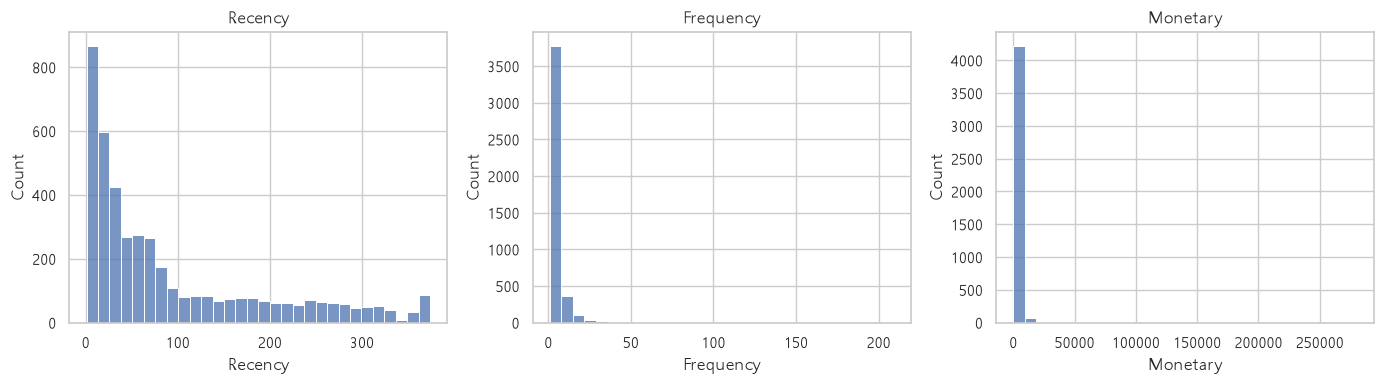

In [131]:
plt.figure(figsize=(14,4))

for idx, col in enumerate(['Recency','Frequency','Monetary'], start=1):
    plt.subplot(1,3,idx)
    sns.histplot(rfm_df[col], bins =30)
    plt.title(col)

plt.tight_layout()
plt.show()

Monetary는 일부 고객이 매우 큰 값을 가져 K-Means같은 거리 기반 알고리즘에 적용하면 변수의 영향이 지나치게 커질 위험이 있다.  
그래서 log1p()로 분포를 완화하고, StandardScaler로 스케일링 작업을 진행해준다.

## 9. 로그 변환과 스케일링
- log1p()로 치우친 분포 완화
- StandardScaler로 평균 0, 표준편차 1 형태로 변환

In [132]:
rfm_features = ['Recency','Frequency','Monetary']

rfm_log = rfm_df[rfm_features].apply(np.log1p)  # 로그 변환

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


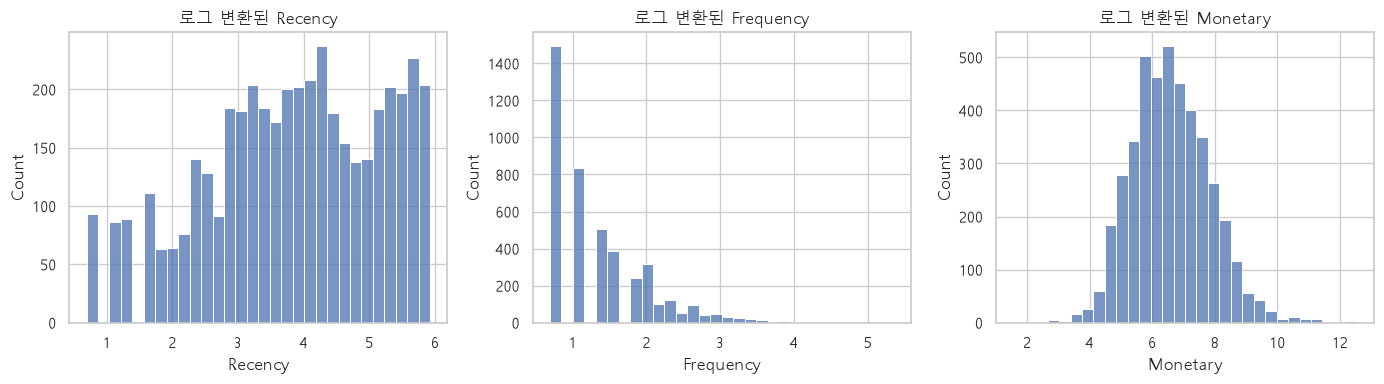

In [133]:
plt.figure(figsize=(14,4))

for idx, col in enumerate(rfm_features, start=1):
    plt.subplot(1,3,idx)
    sns.histplot(rfm_log[col], bins =30)
    plt.title(f"로그 변환된 {col}")

plt.tight_layout()
plt.show()

In [134]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(rfm_log)

scaled_data

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]], shape=(4338, 3))

## 10. 적절한 군집수 K개 선택하기
- 두 개의 기준
    - Elbow Method : 군집 내 거리 합이 급격하게 줄어드는 지점을 확인
    - Shilhouette Score : 군집이 얼마나 잘 분리되었는지 확인

- 실제로는 실제 현실의 해석 가능성 + 비즈니스 활용 가능성

In [135]:

k_values = range(2,9)

inertia_list = []       # K-Means 군집 내 거리 합
silhouette_list = []    # 실루엣 점수

for k in k_values:
    kmeans = KMeans(
        n_clusters= k,      # 군집 개수 2~8
        random_state= SEED, 
        n_init= 10          # 초기 중심점을 10번 바꿔서 가장 좋은 결과를 사용
        )
    
    # 학습 및 군집 라벨 예측
    labels = kmeans.fit_predict(scaled_data)

    inertia_list.append(kmeans.inertia_)    # 각 데이터가 본인의 군집 중심과 얼마나 가까운지 나타내는 값

    sample_size = min(1000, len(scaled_data))   # 최대 1000개의 샘플만 사용
    score = silhouette_score(
        scaled_data,        # 스케일링 된 RFM 데이터
        labels,             # KMeans가 예측한 군집 라벨
        sample_size= sample_size,
        random_state= SEED
    )
    silhouette_list.append(score)

k_result = pd.DataFrame({
    "k" : list(k_values),
    "inertia" : inertia_list,
    'silhouette_score' : silhouette_list
})

k_result

,k,inertia,silhouette_score
0,2,6481.225323,0.429084
1,3,4867.846645,0.332634
2,4,3938.509954,0.334941
3,5,3295.976329,0.317371
4,6,2855.011247,0.317349
5,7,2548.914324,0.311720
6,8,2336.777508,0.298899


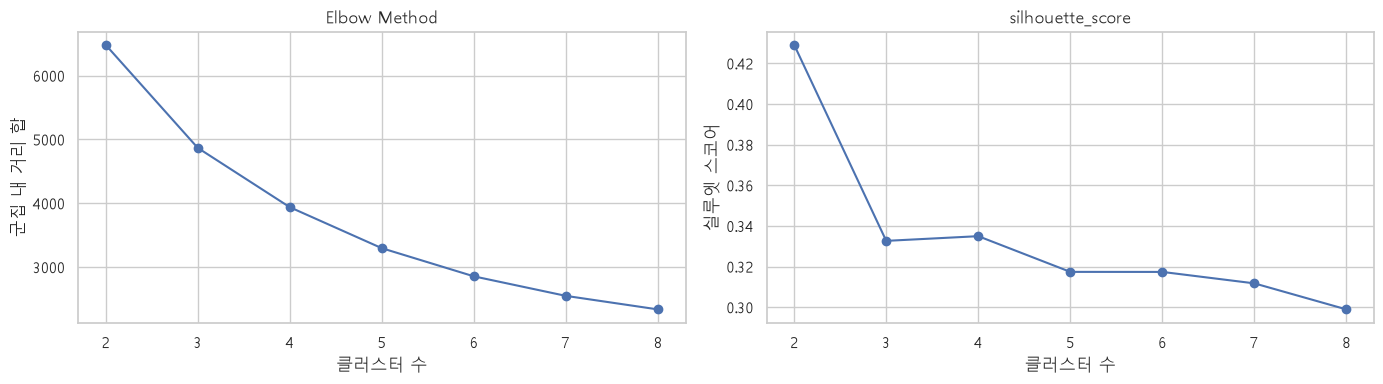

In [136]:
plt.figure(figsize= (14,4))
plt.subplot(1,2,1)
plt.plot(k_result['k'], k_result['inertia'], marker = 'o')
plt.title("Elbow Method")
plt.xlabel('클러스터 수')
plt.ylabel('군집 내 거리 합')

plt.subplot(1,2,2)
plt.plot(k_result['k'], k_result['silhouette_score'], marker = 'o')
plt.title("silhouette_score")
plt.xlabel('클러스터 수')
plt.ylabel('실루엣 스코어')

plt.tight_layout()
plt.show()

k = 4 지표상으로는 적절해 보입니다.  
그렇지만 해석을 편하게 하기위해 k=3으로 가도록 하겠습니다.

## 11. K-Means 군집화

In [137]:
K = 3

kmeans = KMeans(n_clusters= K, random_state= SEED, n_init=10)
rfm_df['cluster'] = kmeans.fit_predict(scaled_data)

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


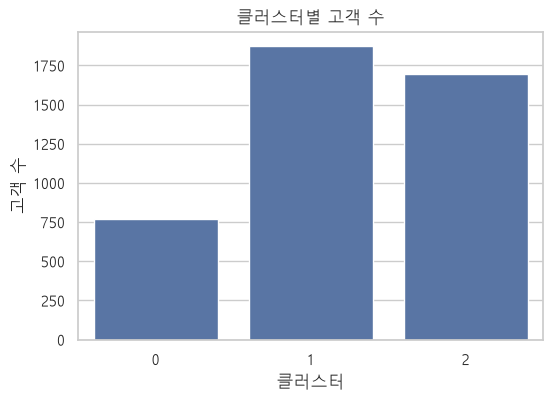

In [138]:
cluster_counts = rfm_df['cluster'].value_counts().sort_index()

plt.figure(figsize= (6,4))

sns.barplot(x= cluster_counts.index, y = cluster_counts.values)
plt.title("클러스터별 고객 수")
plt.xlabel('클러스터')
plt.ylabel('고객 수')
plt.show()

In [139]:
final_silhouette = silhouette_score(
    scaled_data,
    rfm_df['cluster'],
    sample_size=min(1000, len(scaled_data)),
    random_state= SEED
)

final_silhouette

0.3326339810525557

silhouette_score = -1 ~ 1
1에 가까울수록 군집이 잘 분리 되었다.  
0에 가까울수록 군집 경계가 모호하다.  
음수에 가까울수록 다른 군집과 더 가까운 데이터가 많다.  

0.33..-> 아주 낮지는 않지만 고객 데이터 특성상 패턴이 연속적인 면이 있어 실루엣 점수상 안 좋게 나올수 있음

## 12. PCA로 군집 결과 시각화

In [140]:
pca = PCA(n_components=2,random_state=SEED)
pca_data = pca.fit_transform(scaled_data)

rfm_df['pca_x'] = pca_data[:,0] # PCA 첫번째 축
rfm_df['pca_y'] = pca_data[:,1] # PCA 두번째 축

print(f"PCA 1 , 2축 설명 분산 비율 : {pca.explained_variance_ratio_}")
print(f"PCA 누적 설명 분산 비율 : {pca.explained_variance_ratio_.sum()}")

PCA 1 , 2축 설명 분산 비율 : [0.75102042 0.18759201]
PCA 누적 설명 분산 비율 : 0.9386124314129809


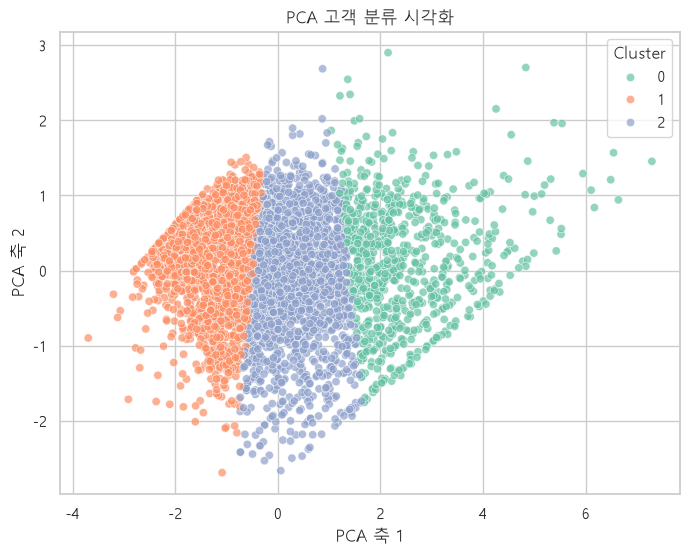

In [141]:
plt.figure(figsize= (8,6))

sns.scatterplot(
    data = rfm_df,
    x = 'pca_x',
    y= "pca_y",
    hue= 'cluster',
    palette = 'Set2',
    alpha = 0.7
)
plt.title("PCA 고객 분류 시각화")
plt.xlabel('PCA 축 1')
plt.ylabel('PCA 축 2')
plt.legend(title = 'Cluster')
plt.show()

군집 간 차이가 비교적 명확하게 분리되어 있다.  
겹치는 부분은 고객의 행동 양식이 연속적인 경우이다.

## 13. 군집별 RFM 특성 해석
- 각 군집이 어떤 고객군인지 해석해보기

In [142]:
cluster_summary = (
    rfm_df
    .groupby('cluster')
    .agg(
        customer_count = ('CustomerID', 'count'),
        recency_mean = ('Recency', 'mean'),
        recency_median = ('Recency', 'median'),
        frequency_mean = ('Frequency', 'mean'),
        frequency_median = ('Frequency', 'median'),
        monetary_mean = ('Monetary', 'mean'),
        monetary_median = ('Monetary', 'median'),
        monetary_sum = ('Monetary', 'sum')
    )
    .round(2)
)

cluster_summary

,customer_count,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,monetary_sum
cluster,,,,,,,,
0,770,17.06,9.0,13.34,10.0,7905.44,3708.34,6087189.20
1,1872,167.36,158.0,1.35,1.0,362.54,298.06,678670.41
2,1696,44.21,30.0,3.38,3.0,1265.06,979.19,2145548.29


recency가 낮다 -> 최근에 구매한 고객  
frequency가 높다 -> 자주 구매한 고객  
monetary가 높다 -> 구매금액이 큰 고객  

  
cluster 0이 VIP  
cluster 1이 휴면 고객  
cluster 2이 일반 고객  



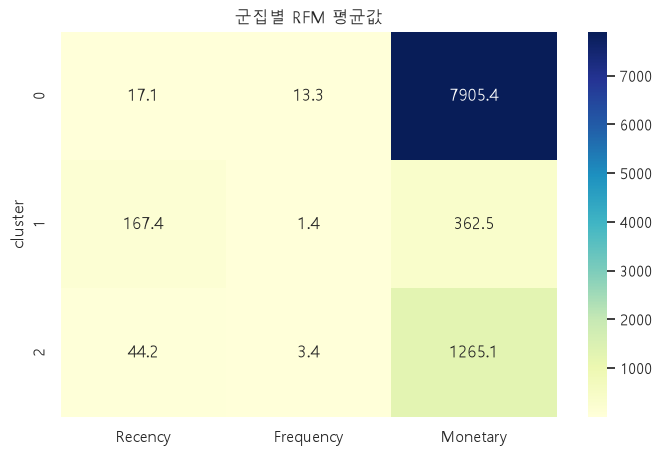

In [143]:
cluster_profile = rfm_df.groupby('cluster')[rfm_features].mean()


plt.figure(figsize= (8,5))

sns.heatmap(
    cluster_profile,
    annot= True,
    fmt = '.1f',
    cmap = 'YlGnBu'
)
plt.title("군집별 RFM 평균값")
plt.show()